In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Trips_by_Distance.csv to Trips_by_Distance.csv


In [ ]:
df = pd.read_csv("Trips_by_Distance.csv")
ddf = dd.read_csv("Trips_by_Distance.csv")

In [ ]:
print(df.head())
print(df.columns)

      Level      Date  State FIPS State Postal Code  County FIPS County Name  \
0  National  1/1/2019         NaN               NaN          NaN         NaN   
1  National  1/2/2019         NaN               NaN          NaN         NaN   
2  National  1/3/2019         NaN               NaN          NaN         NaN   
3  National  1/4/2019         NaN               NaN          NaN         NaN   
4  National  1/5/2019         NaN               NaN          NaN         NaN   

   Population Staying at Home  Population Not Staying at Home  \
0                  77433867.0                     248733553.0   
1                  61305201.0                     264862219.0   
2                  63050480.0                     263116940.0   
3                  61803652.0                     264363768.0   
4                  64389745.0                     261777675.0   

   Number of Trips  Number of Trips <1  ...  Number of Trips 5-10  \
0     8.977844e+08         241667151.0  ...           12967

In [ ]:
print(df.columns)

Index(['Level', 'Date', 'State FIPS', 'State Postal Code', 'County FIPS',
       'County Name', 'Population Staying at Home',
       'Population Not Staying at Home', 'Number of Trips',
       'Number of Trips <1', 'Number of Trips 1-3', 'Number of Trips 3-5',
       'Number of Trips 5-10', 'Number of Trips 10-25',
       'Number of Trips 25-50', 'Number of Trips 50-100',
       'Number of Trips 100-250', 'Number of Trips 250-500',
       'Number of Trips >=500', 'Row ID', 'Week', 'Month'],
      dtype='object')


In [ ]:
weekly_home = df.groupby("Week")["Population Staying at Home"].sum().reset_index()

print(weekly_home)

    Week  Population Staying at Home
0      0                1.952541e+09
1      1                3.472721e+09
2      2                3.436196e+09
3      3                3.374846e+09
4      4                3.372764e+09
5      5                3.335111e+09
6      6                3.308466e+09
7      7                3.379386e+09
8      8                3.199165e+09
9      9                3.195782e+09
10    10                3.205834e+09
11    11                3.536231e+09
12    12                3.590493e+09
13    13                3.635026e+09
14    14                3.636967e+09
15    15                3.662526e+09
16    16                3.556236e+09
17    17                3.550206e+09
18    18                3.546244e+09
19    19                3.417806e+09
20    20                3.263274e+09
21    21                3.441127e+09
22    22                3.406186e+09
23    23                3.848151e+09
24    24                3.887882e+09
25    25                2.401984e+09
2

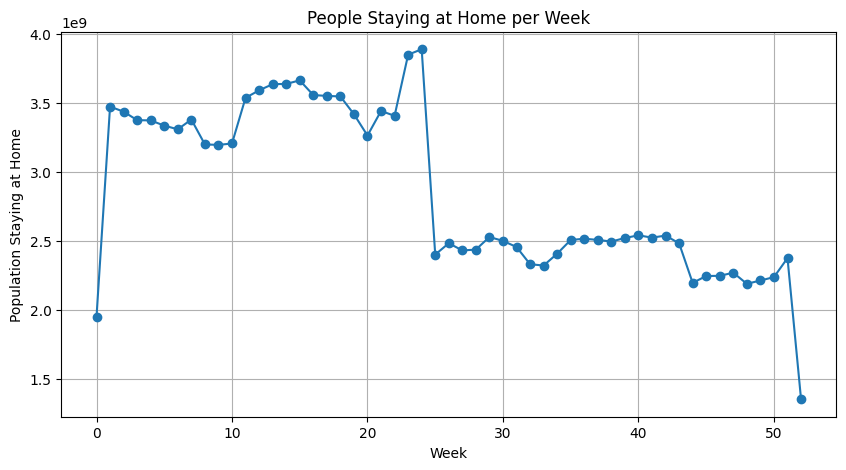

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(weekly_home["Week"], weekly_home["Population Staying at Home"], marker='o')
plt.title("People Staying at Home per Week")
plt.xlabel("Week")
plt.ylabel("Population Staying at Home")
plt.grid(True)
plt.show()


In [ ]:
distance_cols = [
    "Number of Trips <1",
    "Number of Trips 1-3",
    "Number of Trips 3-5",
    "Number of Trips 5-10",
    "Number of Trips 10-25",
    "Number of Trips 25-50",
    "Number of Trips 50-100",
    "Number of Trips 100-250",
    "Number of Trips 250-500",
    "Number of Trips >=500"
]

distance_totals = df[distance_cols].sum().sort_values()

print(distance_totals)


Number of Trips >=500      3.254191e+09
Number of Trips 250-500    3.679793e+09
Number of Trips 100-250    1.638828e+10
Number of Trips 50-100     4.023105e+10
Number of Trips 25-50      1.251168e+11
Number of Trips 3-5        3.149226e+11
Number of Trips 10-25      3.893308e+11
Number of Trips 5-10       3.980011e+11
Number of Trips <1         6.338851e+11
Number of Trips 1-3        6.412559e+11
dtype: float64


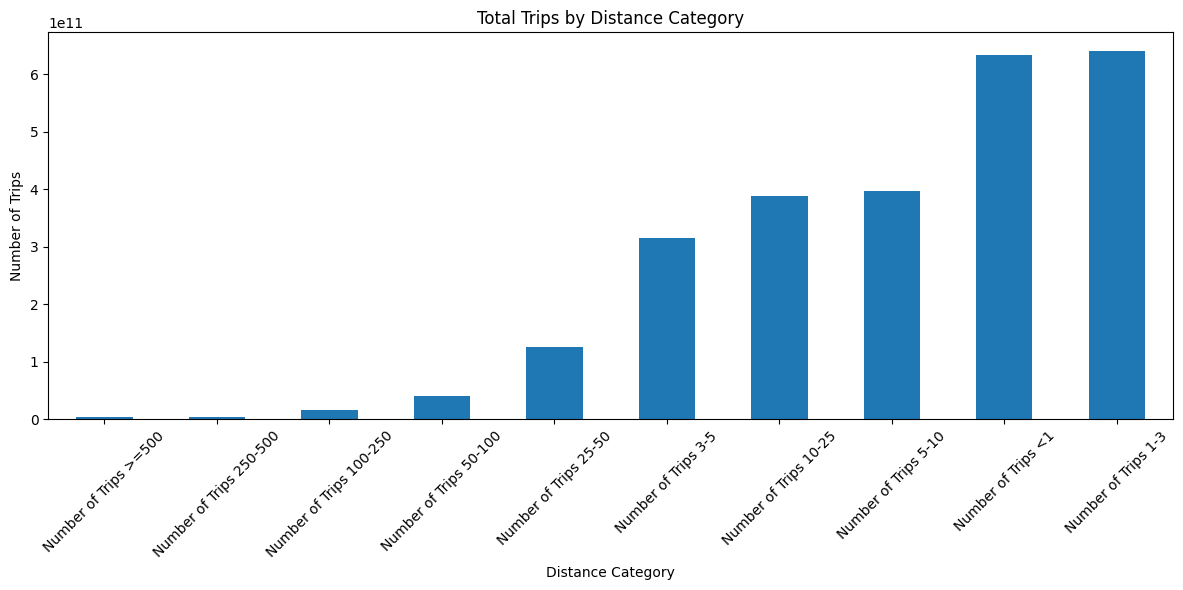

In [ ]:
plt.figure(figsize=(12,6))
distance_totals.plot(kind="bar")
plt.title("Total Trips by Distance Category")
plt.xlabel("Distance Category")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

In [ ]:
group_10_25 = df[df["Number of Trips 10-25"] > 10_000_000][["Date", "Number of Trips 10-25"]]
group_50_100 = df[df["Number of Trips 50-100"] > 10_000_000][["Date", "Number of Trips 50-100"]]

In [ ]:
print("Dates with >10,000,000 (10-25 trips):")
print(group_10_25)

print("\nDates with >10,000,000 (50-100 trips):")
print(group_50_100)

Dates with >10,000,000 (10-25 trips):
             Date  Number of Trips 10-25
0      2019-01-01            116904343.0
1      2019-01-02            167412698.0
2      2019-01-03            172027487.0
3      2019-01-04            176144493.0
4      2019-01-05            165239790.0
...           ...                    ...
157189 2021-06-15            200549282.0
157190 2021-06-16            199082591.0
157191 2021-06-17            198280332.0
157192 2021-06-18            202609024.0
157193 2021-06-19            178997864.0

[3749 rows x 2 columns]

Dates with >10,000,000 (50-100 trips):
             Date  Number of Trips 50-100
0      2019-01-01              15686639.0
1      2019-01-02              17739183.0
2      2019-01-03              18366626.0
3      2019-01-04              19315785.0
4      2019-01-05              19363939.0
...           ...                     ...
157189 2021-06-15              19181256.0
157190 2021-06-16              19247409.0
157191 2021-06-17          

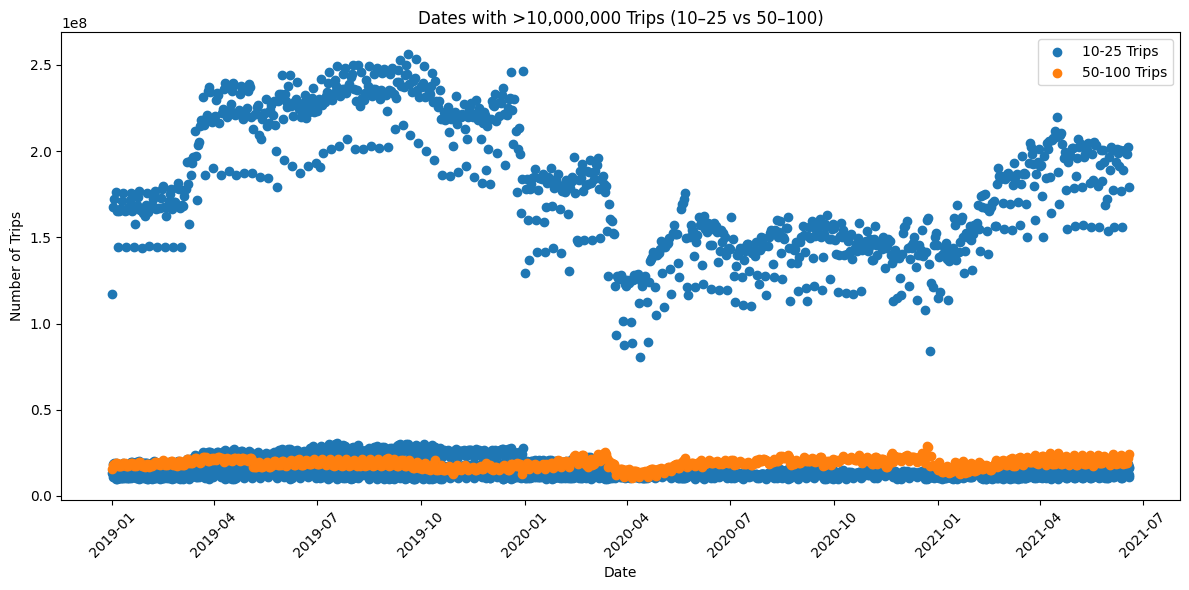

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Plot ONLY filtered data
plt.scatter(group_10_25["Date"], group_10_25["Number of Trips 10-25"], label="10-25 Trips")
plt.scatter(group_50_100["Date"], group_50_100["Number of Trips 50-100"], label="50-100 Trips")

plt.title("Dates with >10,000,000 Trips (10–25 vs 50–100)")
plt.xlabel("Date")
plt.ylabel("Number of Trips")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Distance mapping
distance_map = {
    "Number of Trips <1": 0.5,
    "Number of Trips 1-3": 2,
    "Number of Trips 3-5": 4,
    "Number of Trips 5-10": 7.5,
    "Number of Trips 10-25": 17.5,
    "Number of Trips 25-50": 37.5,
    "Number of Trips 50-100": 75,
    "Number of Trips 100-250": 175,
    "Number of Trips 250-500": 375,
    "Number of Trips >=500": 500
}

In [ ]:
# 2. Convert to long format
long_df = df.melt(
    id_vars=["Date"],
    value_vars=list(distance_map.keys()),
    var_name="Distance_Category",
    value_name="Trip_Frequency"
)

long_df["Distance_Value"] = long_df["Distance_Category"].map(distance_map)

In [ ]:
# 3. Remove NaN rows
long_df = long_df.dropna(subset=["Trip_Frequency", "Distance_Value"])

In [ ]:
# 4. Train-test split
from sklearn.model_selection import train_test_split

X = long_df[["Distance_Value"]]
y = long_df["Trip_Frequency"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 5. Train model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# 6. Predict
y_pred = model.predict(X_test)

In [ ]:
# 7. Evaluation
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 4978880.395089509
R2: 0.0010204997601858112


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


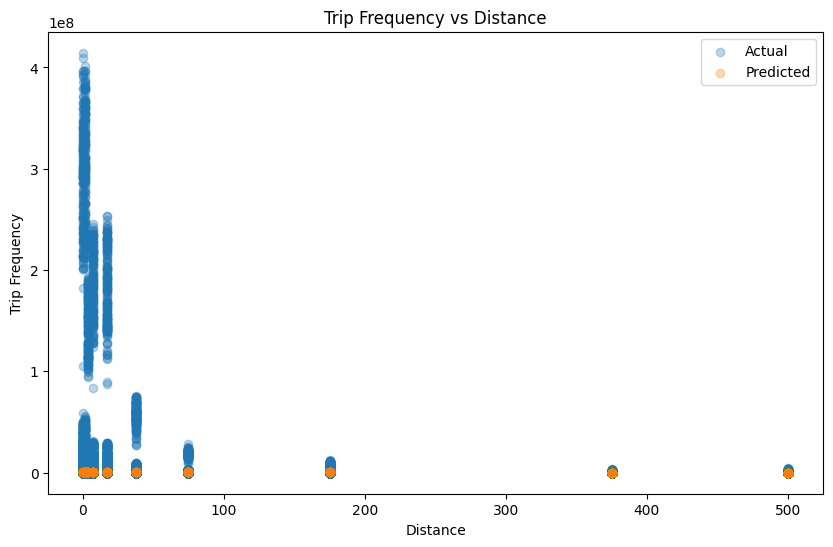

In [ ]:
# 8. Scatterplot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, alpha=0.3, label="Actual")
plt.scatter(X_test, y_pred, alpha=0.3, label="Predicted")
plt.xlabel("Distance")
plt.ylabel("Trip Frequency")
plt.title("Trip Frequency vs Distance")
plt.legend()
plt.show()

In [ ]:
# Total travellers by distance
distance_totals = df[[
    "Number of Trips <1",
    "Number of Trips 1-3",
    "Number of Trips 3-5",
    "Number of Trips 5-10",
    "Number of Trips 10-25",
    "Number of Trips 25-50",
    "Number of Trips 50-100",
    "Number of Trips 100-250",
    "Number of Trips 250-500",
    "Number of Trips >=500"
]].sum()

# Keep logical order
distance_cols = [
    "Number of Trips <1",
    "Number of Trips 1-3",
    "Number of Trips 3-5",
    "Number of Trips 5-10",
    "Number of Trips 10-25",
    "Number of Trips 25-50",
    "Number of Trips 50-100",
    "Number of Trips 100-250",
    "Number of Trips 250-500",
    "Number of Trips >=500"
]

distance_totals = distance_totals.reindex(distance_cols)

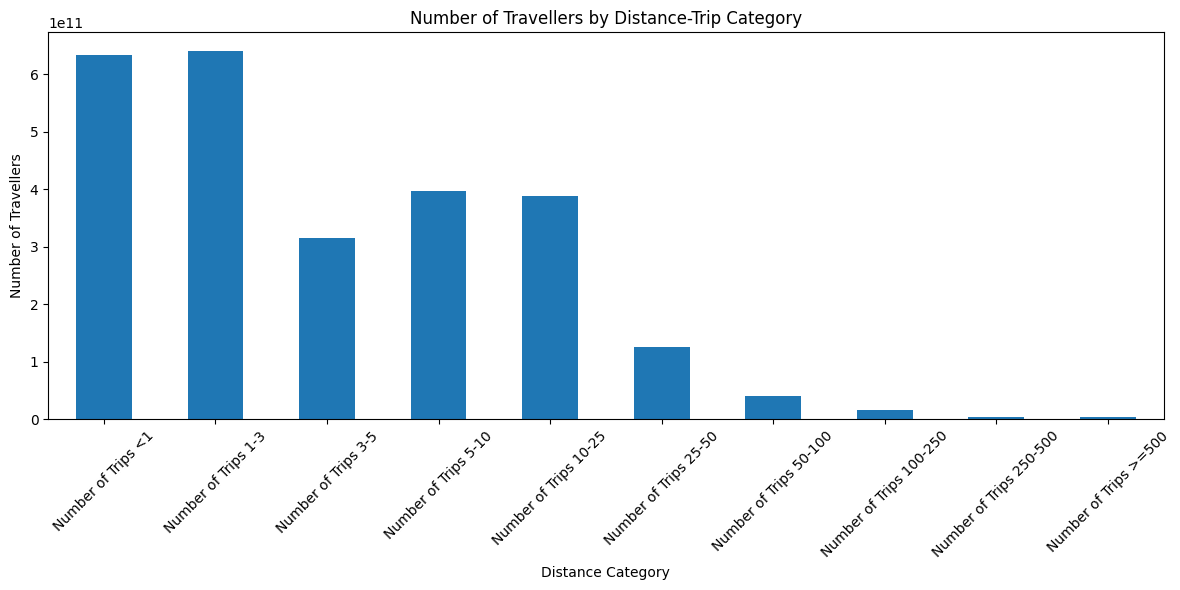

In [ ]:
# Bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
distance_totals.plot(kind="bar")

plt.title("Number of Travellers by Distance-Trip Category")
plt.xlabel("Distance Category")
plt.ylabel("Number of Travellers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
!pip install "dask[distributed]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.6 MB/s eta 0:00:00


In [ ]:
import time
import pandas as pd
import dask.dataframe as dd
from dask.distributed import Client, LocalCluster

In [ ]:
# Pandas timing
start = time.time()

df = pd.read_csv("Trips_by_Distance.csv")
weekly_home = df.groupby("Week")["Population Staying at Home"].sum()

pandas_time = time.time() - start
print("Pandas time:", pandas_time)

Pandas time: 6.405057907104492


In [ ]:
ddf = dd.read_csv(
    "Trips_by_Distance.csv",
    assume_missing=True,
    dtype={
        "County Name": "object",
        "State Postal Code": "object"
    }
)

In [ ]:
from dask.distributed import Client, LocalCluster
import dask.dataframe as dd
import time

In [2]:
!pip install "dask[distributed]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.8 MB/s eta 0:00:00


In [4]:
from google.colab import files
uploaded = files.upload()

Saving Trips_by_Distance.csv to Trips_by_Distance.csv


In [5]:
from dask.distributed import Client, LocalCluster
import dask.dataframe as dd
import time

cluster10 = LocalCluster(n_workers=4, threads_per_worker=1)
client10 = Client(cluster10)

start = time.time()

ddf = dd.read_csv(
    "Trips_by_Distance.csv",
    assume_missing=True,
    dtype={
        "County Name": "object",
        "State Postal Code": "object"
    }
)

result = ddf.groupby("Week")["Population Staying at Home"].sum().compute()

end = time.time()

print("Dask (10 workers):", round(end - start, 2), "seconds")

client10.close()
cluster10.close()

/usr/local/lib/python3.12/dist-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37289 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:42301
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:37289/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:43329'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40361'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:38833'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40591'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:42353 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:42353
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:58232
INFO:distributed.sch

Dask (10 workers): 9.11 seconds


INFO:distributed.nanny:Nanny at 'tcp://127.0.0.1:43329' closed.
INFO:distributed.nanny:Nanny at 'tcp://127.0.0.1:40361' closed.
INFO:distributed.nanny:Nanny at 'tcp://127.0.0.1:38833' closed.
INFO:distributed.nanny:Nanny at 'tcp://127.0.0.1:40591' closed.
INFO:distributed.scheduler:Closing scheduler. Reason: unknown
INFO:distributed.scheduler:Scheduler closing all comms


In [6]:
from dask.distributed import Client, LocalCluster
import dask.dataframe as dd
import time

# simulate 20 workers (safe)
cluster20 = LocalCluster(n_workers=8, threads_per_worker=1)
client20 = Client(cluster20)

start = time.time()

ddf = dd.read_csv(
    "Trips_by_Distance.csv",
    assume_missing=True,
    dtype={
        "County Name": "object",
        "State Postal Code": "object"
    }
)

result = ddf.groupby("Week")["Population Staying at Home"].sum().compute()

end = time.time()

print("Dask (20 workers):", round(end - start, 2), "seconds")

client20.close()
cluster20.close()

/usr/local/lib/python3.12/dist-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33497 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:38963
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:33497/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:38989'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:39489'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:43261'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:44235'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40743'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:41401'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:42129'
INFO:distributed.nanny:        Start Nanny at:

Dask (20 workers): 12.67 seconds


INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:46576; closing.
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:46564; closing.
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:46560; closing.
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:46570; closing.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:37667 name: 0 (stimulus_id='handle-worker-cleanup-1774904476.0598617')
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:45677 name: 1 (stimulus_id='handle-worker-cleanup-1774904476.0744176')
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:36147 name: 2 (stimulus_id='handle-worker-cleanup-1774904476.0846694')
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:36439 name: 3 (stimulus_id='handle-worker-cleanup-1774904476.092368')
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:42441 name: 4 (stimulus_id='handle-worker-cleanup-1774904476.103241')


In [13]:
import pandas as pd

df = pd.read_csv("Trips_by_Distance.csv")

In [16]:
distance_map = {
    "Number of Trips <1": 0.5,
    "Number of Trips 1-3": 2,
    "Number of Trips 3-5": 4,
    "Number of Trips 5-10": 7.5,
    "Number of Trips 10-25": 17.5,
    "Number of Trips 25-50": 37.5,
    "Number of Trips 50-100": 75,
    "Number of Trips 100-250": 175,
    "Number of Trips 250-500": 375,
    "Number of Trips >=500": 500
}

long_df = df.melt(
    id_vars=["Date"],
    value_vars=list(distance_map.keys()),
    var_name="Distance_Category",
    value_name="Trip_Frequency"
)

long_df["Distance_Value"] = long_df["Distance_Category"].map(distance_map)

In [18]:
# Split data
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# remove missing values first
model_df = long_df.dropna(subset=["Distance_Value", "Trip_Frequency"])

X = model_df[["Distance_Value"]]
y = model_df["Trip_Frequency"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 2))

RMSE: 4978880.4
R2: 0.0
